# Predicting Trip Duration
Use `nnlib` to predict NYC taxi trip duration.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nnlib import LinearLayer, RectifiedLinearUnit, Sequential, MeanSquaredErrorLoss

np.random.seed(0)

dataset = np.load("data/nyc_taxi_data.npy", allow_pickle=True).item()
X_train, y_train, X_test, y_test = dataset["X_train"], dataset["y_train"], dataset["X_test"], dataset["y_test"]
X_train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
879655,id2425795,1,2016-01-08 23:55:11,2016-01-09 00:04:32,1,-73.955551,40.773346,-73.973640,40.763500,N
646838,id0767831,2,2016-03-05 09:52:06,2016-03-05 10:00:12,1,-73.962181,40.763599,-73.980377,40.764919,N
1138713,id0449104,1,2016-04-09 16:03:53,2016-04-09 16:21:22,1,-73.977486,40.751842,-74.011688,40.718925,N
864716,id3030157,1,2016-01-06 11:12:44,2016-01-06 11:19:49,1,-73.970001,40.762363,-73.963264,40.774666,N
434927,id1584885,1,2016-06-26 09:10:56,2016-06-26 09:17:44,1,-73.950348,40.771561,-73.968178,40.762409,N


## Dataset Preprocessing

### Target

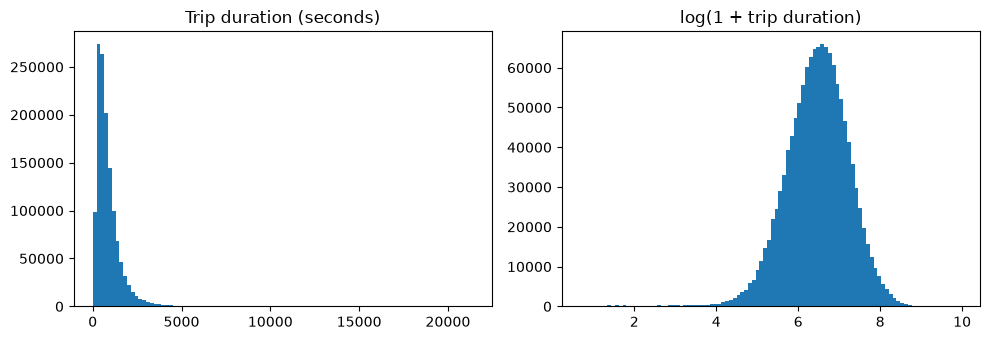

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(y_train[y_train < 6 * 3600], bins=100)
axes[0].set_title("Trip duration (seconds)")
axes[1].hist(np.log1p(y_train[y_train < 6 * 3600]), bins=100)
axes[1].set_title("log(1 + trip duration)")
plt.tight_layout()
plt.savefig("docs/figures/target_distribution.png")
plt.show()

The duration is very skewed, so the model predicts `log(1 + duration)` instead. Training trips longer than
6 hours are removed as recording errors.

### Features

In [3]:
def haversine(lat1, lon1, lat2, lon2):
    """Distance in km between two points given in degrees."""
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))


def raw_features(df):
    """Numeric columns of the dataset as they are. id and dropoff_datetime are dropped
    (dropoff_datetime gives away the answer)."""
    return pd.DataFrame({
        "vendor_id": df["vendor_id"],
        "passenger_count": df["passenger_count"],
        "pickup_longitude": df["pickup_longitude"],
        "pickup_latitude": df["pickup_latitude"],
        "dropoff_longitude": df["dropoff_longitude"],
        "dropoff_latitude": df["dropoff_latitude"],
        "store_and_fwd_flag": (df["store_and_fwd_flag"] == "Y").astype(int),
    }).astype(float)


def engineered_features(df):
    """Raw features plus trip distance and the time of the pickup."""
    f = raw_features(df)
    time = pd.to_datetime(df["pickup_datetime"])
    f["distance"] = np.log1p(haversine(df["pickup_latitude"], df["pickup_longitude"],
                                       df["dropoff_latitude"], df["dropoff_longitude"]))
    f["hour"] = time.dt.hour
    f["weekday"] = time.dt.weekday
    f["month"] = time.dt.month
    return f

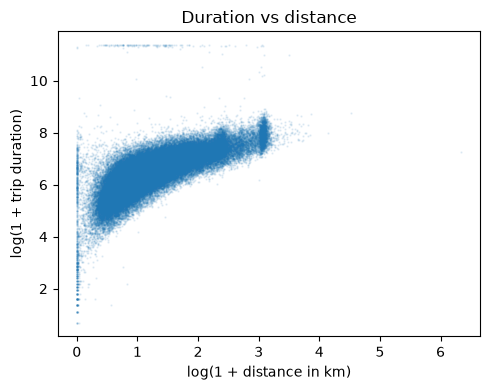

In [4]:
sample = X_train.sample(100_000, random_state=0)
distance = haversine(sample["pickup_latitude"], sample["pickup_longitude"],
                     sample["dropoff_latitude"], sample["dropoff_longitude"])
plt.figure(figsize=(5, 4))
plt.scatter(np.log1p(distance), np.log1p(y_train[sample.index]), s=0.5, alpha=0.1)
plt.xlabel("log(1 + distance in km)")
plt.ylabel("log(1 + trip duration)")
plt.title("Duration vs distance")
plt.tight_layout()
plt.savefig("docs/figures/duration_vs_distance.png")
plt.show()

### Train / validation split and normalization
10% of the training data is used as the validation set. Features and the target are standardized with the mean
and standard deviation of the training split. Standardized features are clipped to [-5, 5] because a few
coordinates are far outside New York and would otherwise make training diverge.

In [5]:
keep = y_train <= 6 * 3600
X_clean, y_clean = X_train[keep], np.log1p(y_train[keep].values).reshape(-1, 1)
y_te = np.log1p(y_test.values).reshape(-1, 1)

order = np.random.permutation(len(X_clean))
val_idx, tr_idx = order[:len(order) // 10], order[len(order) // 10:]
y_mean, y_std = y_clean[tr_idx].mean(), y_clean[tr_idx].std()
y_tr, y_val = (y_clean[tr_idx] - y_mean) / y_std, (y_clean[val_idx] - y_mean) / y_std


def prepare(feature_fn):
    """Build the features for train, validation and test and standardize them."""
    f = feature_fn(X_clean).values
    f_test = feature_fn(X_test).values
    mean, std = f[tr_idx].mean(axis=0), f[tr_idx].std(axis=0)
    scale = lambda x: np.clip((x - mean) / std, -5, 5)
    return scale(f[tr_idx]), scale(f[val_idx]), scale(f_test)

### Training with early stopping
Training stops when the validation loss does not improve for 3 epochs.

In [6]:
def build_model(n_inputs, hidden_sizes):
    """Linear + ReLU for each hidden layer, then one linear output."""
    layers = []
    for size in hidden_sizes:
        layers += [LinearLayer(n_inputs, size), RectifiedLinearUnit()]
        n_inputs = size
    layers.append(LinearLayer(n_inputs, 1))
    return Sequential(layers)


def train(model, X_tr, y_tr, X_val, y_val, lr=0.01, batch_size=512, max_epochs=100, patience=3):
    """Mini-batch gradient descent with early stopping. Returns the train and validation losses."""
    loss_fn = MeanSquaredErrorLoss()
    train_losses, val_losses = [], []
    best, epochs_without_improvement = np.inf, 0

    for epoch in range(max_epochs):
        order = np.random.permutation(len(X_tr))
        for start in range(0, len(X_tr), batch_size):
            batch = order[start:start + batch_size]
            loss_fn.forward(model.forward(X_tr[batch]), y_tr[batch])
            model.backward(loss_fn.backward())
            model.step(lr)

        train_losses.append(loss_fn.forward(model.forward(X_tr), y_tr))
        val_losses.append(loss_fn.forward(model.forward(X_val), y_val))

        if val_losses[-1] < best:
            best, epochs_without_improvement = val_losses[-1], 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement == patience:
                break

    return train_losses, val_losses

### Comparing features
The same small model (one hidden layer of 32 nodes) is trained on the raw features and on the engineered features.

In [7]:
for name, feature_fn in [("raw features", raw_features), ("engineered features", engineered_features)]:
    X_tr, X_val, X_te = prepare(feature_fn)
    model = build_model(X_tr.shape[1], [32])
    train_losses, val_losses = train(model, X_tr, y_tr, X_val, y_val)
    print(f"{name}: best validation loss {min(val_losses):.4f}")

raw features: best validation loss 0.3285


engineered features: best validation loss 0.2706


The engineered features give a lower validation loss, so they are used for the models below.

## Model Selection

[16]: stopped after 87 epochs, best validation loss 0.2712


[64, 32]: stopped after 46 epochs, best validation loss 0.2513


[128, 64, 32]: stopped after 61 epochs, best validation loss 0.2449


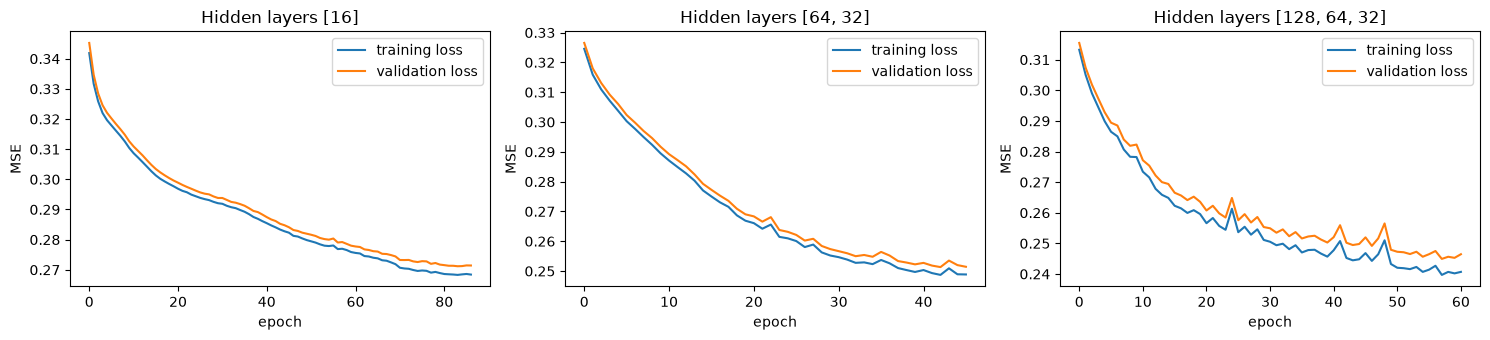

In [8]:
X_tr, X_val, X_te = prepare(engineered_features)

configs = {"[16]": [16], "[64, 32]": [64, 32], "[128, 64, 32]": [128, 64, 32]}
models = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, (name, hidden) in zip(axes, configs.items()):
    models[name] = build_model(X_tr.shape[1], hidden)
    train_losses, val_losses = train(models[name], X_tr, y_tr, X_val, y_val)
    ax.plot(train_losses, label="training loss")
    ax.plot(val_losses, label="validation loss")
    ax.set_title(f"Hidden layers {name}")
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE")
    ax.legend()
    print(f"{name}: stopped after {len(val_losses)} epochs, best validation loss {min(val_losses):.4f}")
plt.tight_layout()
plt.show()

### Test set
The test loss is the mean squared error of log(1 + duration). Trip duration is a regression target, so accuracy
is measured as the share of test trips whose predicted duration is within 25% of the true duration.

In [9]:
loss_fn = MeanSquaredErrorLoss()
for name, model in models.items():
    pred = model.forward(X_te) * y_std + y_mean
    test_loss = loss_fn.forward(pred, y_te)
    accuracy = np.mean(np.abs(np.expm1(pred) - np.expm1(y_te)) <= 0.25 * np.expm1(y_te))
    print(f"{name}: test loss {test_loss:.4f}, test accuracy {accuracy:.1%}")

[16]: test loss 0.1982, test accuracy 56.6%


[64, 32]: test loss 0.1875, test accuracy 59.9%


[128, 64, 32]: test loss 0.1826, test accuracy 59.2%
